# Transformer-Based Electricity Consumption Forecasting

## 1. Setup

In [1]:
# Import

import math
import joblib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# Set random seed for reproducibility

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
# Select available device

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: cpu


## 2. Data Loading & Cleaning

In [4]:
# Load dataset

file_path = Path("../data/household_power_consumption.txt")

df = pd.read_csv(
    file_path,
    sep=";",
    na_values="?",
    low_memory=False
)

print("Original shape:", df.shape)

df.head()

Original shape: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [5]:
# Inspect dataset

df.info()

# Display column names

print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), str(2)
memory usage: 142.5 MB
['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


In [6]:
# Combine Date and Time into one timestamp column

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    format="%d/%m/%Y %H:%M:%S",
    errors="coerce"
)

print("Invalid timestamps:", df["Datetime"].isna().sum())

Invalid timestamps: 0


In [7]:
# Organize time-series data

df = df.drop(columns=["Date", "Time"])
df = df.dropna(subset=["Datetime"])
df = df.sort_values("Datetime")
df = df.set_index("Datetime")

df = df.apply(pd.to_numeric, errors="coerce")

print("Updated shape:", df.shape)
print("Start date:", df.index.min())
print("End date:", df.index.max())
print("Duplicate timestamps:", df.index.duplicated().sum())

df.head()

Updated shape: (2075259, 7)
Start date: 2006-12-16 17:24:00
End date: 2010-11-26 21:02:00
Duplicate timestamps: 0


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [8]:
# Remove duplicate timestamps

df = df[~df.index.duplicated(keep="first")]

print("Duplicate timestamps:", df.index.duplicated().sum())

Duplicate timestamps: 0


In [9]:
# Examine missing values

missing_counts = df.isna().sum()
missing_percentages = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Percentage": missing_percentages
})

missing_summary

# Count rows with missing values

rows_with_missing = df.isna().any(axis=1).sum()
missing_row_percentage = (rows_with_missing / len(df)) * 100

print("Rows with missing values:", rows_with_missing)
print(f"Percentage of rows with missing values: {missing_row_percentage:.2f}%")

Rows with missing values: 25979
Percentage of rows with missing values: 1.25%


## 3. Resampling & Exploration

In [10]:
# Resample data into hourly averages

hourly_df = df.resample("h").mean()

print("Hourly shape:", hourly_df.shape)

hourly_df.head()

Hourly shape: (34589, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [11]:
# Inspect hourly dataset

hourly_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 34589 entries, 2006-12-16 17:00:00 to 2010-11-26 21:00:00
Freq: h
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Global_active_power    34168 non-null  float64
 1   Global_reactive_power  34168 non-null  float64
 2   Voltage                34168 non-null  float64
 3   Global_intensity       34168 non-null  float64
 4   Sub_metering_1         34168 non-null  float64
 5   Sub_metering_2         34168 non-null  float64
 6   Sub_metering_3         34168 non-null  float64
dtypes: float64(7)
memory usage: 2.1 MB


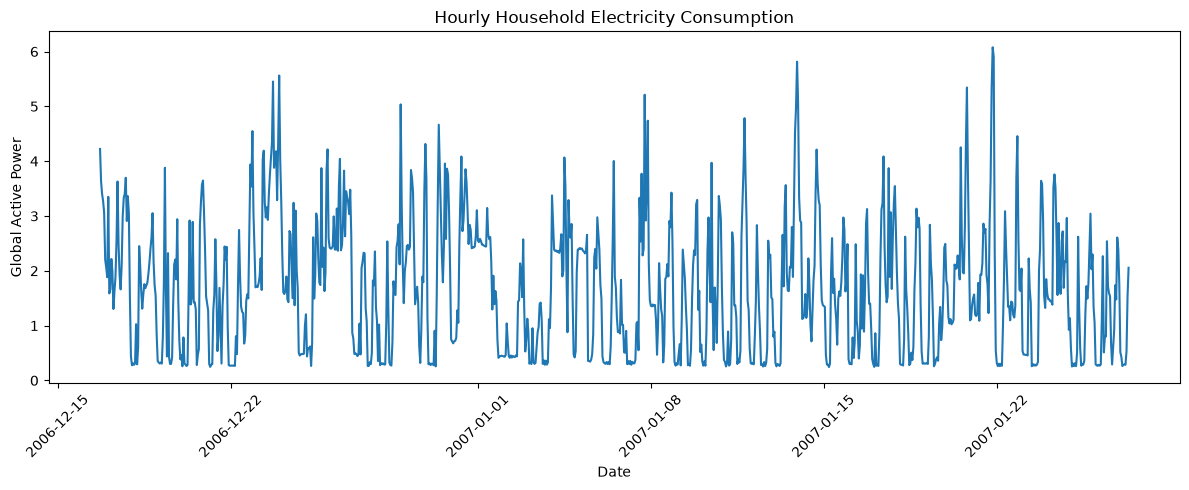

In [12]:
# Plot hourly electricity consumption

plt.figure(figsize=(12, 5))

plt.plot(
    hourly_df.index[:1000],
    hourly_df["Global_active_power"][:1000]
)

plt.title("Hourly Household Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../figures/hourly_electricity_consumption.png")
plt.show()

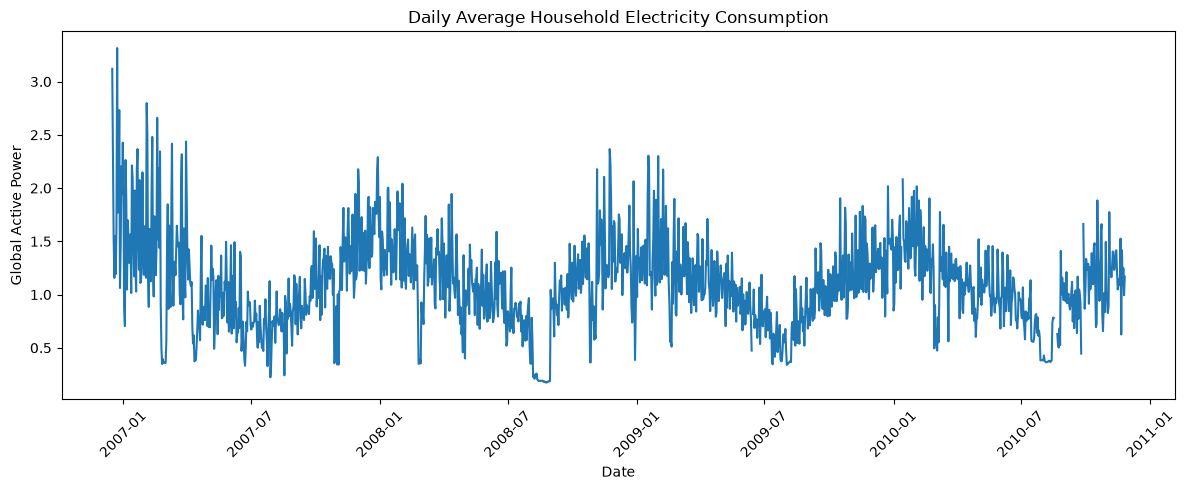

In [13]:
# Plot daily average electricity consumption

daily_power = hourly_df["Global_active_power"].resample("D").mean()

plt.figure(figsize=(12, 5))

plt.plot(
    daily_power.index,
    daily_power
)

plt.title("Daily Average Household Electricity Consumption")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../figures/daily_average_electricity_consumption.png")
plt.show()

## 4. Feature Selection, Train/Val/Test Split & Scaling

In [14]:
# Select input features and target

feature_columns = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

target_column = "Global_active_power"

model_df = hourly_df[feature_columns].copy()

print("Model dataset shape:", model_df.shape)
print("Missing values (to be filled per-split after the train/val/test split):", model_df.isna().sum().sum())

model_df.head()

Model dataset shape: (34589, 7)
Missing values (to be filled per-split after the train/val/test split): 2947


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [15]:
# Split dataset chronologically

train_end = int(len(model_df) * 0.70)
validation_end = int(len(model_df) * 0.85)

train_df = model_df.iloc[:train_end]
validation_df = model_df.iloc[train_end:validation_end]
test_df = model_df.iloc[validation_end:]

print("Training shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (24212, 7)
Validation shape: (5188, 7)
Testing shape: (5189, 7)


In [16]:
# Fill missing values independently within each split to avoid leakage across split boundaries

train_df = train_df.interpolate(method="time", limit_direction="both")
validation_df = validation_df.interpolate(method="time", limit_direction="both")
test_df = test_df.interpolate(method="time", limit_direction="both")

print("Remaining missing values (train):", train_df.isna().sum().sum())
print("Remaining missing values (validation):", validation_df.isna().sum().sum())
print("Remaining missing values (test):", test_df.isna().sum().sum())

Remaining missing values (train): 0
Remaining missing values (validation): 0
Remaining missing values (test): 0


In [17]:
# Scale features and target

feature_scaler = StandardScaler()
target_scaler = StandardScaler()

train_features = feature_scaler.fit_transform(
    train_df[feature_columns]
)

validation_features = feature_scaler.transform(
    validation_df[feature_columns]
)

test_features = feature_scaler.transform(
    test_df[feature_columns]
)

train_targets = target_scaler.fit_transform(
    train_df[[target_column]]
).flatten()

validation_targets = target_scaler.transform(
    validation_df[[target_column]]
).flatten()

test_targets = target_scaler.transform(
    test_df[[target_column]]
).flatten()

print("Training features shape:", train_features.shape)
print("Training targets shape:", train_targets.shape)

Training features shape: (24212, 7)
Training targets shape: (24212,)


## 5. Sequence Dataset & DataLoaders

In [18]:
# Create time-series sequences

class ElectricityDataset(Dataset):

    def __init__(self, features, targets, sequence_length):
        self.features = torch.tensor(
            features,
            dtype=torch.float32
        )

        self.targets = torch.tensor(
            targets,
            dtype=torch.float32
        )

        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.features) - self.sequence_length

    def __getitem__(self, index):
        x = self.features[
            index:index + self.sequence_length
        ]

        y = self.targets[
            index + self.sequence_length
        ]

        return x, y


def build_dataloaders(sequence_length, batch_size, loader_seed=None):
    train_dataset = ElectricityDataset(train_features, train_targets, sequence_length)
    validation_dataset = ElectricityDataset(validation_features, validation_targets, sequence_length)
    test_dataset = ElectricityDataset(test_features, test_targets, sequence_length)

    loader_generator = torch.Generator()
    loader_generator.manual_seed(loader_seed if loader_seed is not None else seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        generator=loader_generator
    )

    validation_loader = DataLoader(
        validation_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0
    )

    return train_dataset, validation_dataset, test_dataset, train_loader, validation_loader, test_loader

In [19]:
# Create default datasets and data loaders (re-built later with Hyperopt-selected sequence_length/batch_size)

sequence_length = 24
batch_size = 64

train_dataset, validation_dataset, test_dataset, train_loader, validation_loader, test_loader = build_dataloaders(
    sequence_length, batch_size
)

print("Training sequences:", len(train_dataset))
print("Validation sequences:", len(validation_dataset))
print("Testing sequences:", len(test_dataset))

Training sequences: 24188
Validation sequences: 5164
Testing sequences: 5165


## 6. Model Architecture

In [ ]:
# Define positional encoding

class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_length=5000):
        super().__init__()

        position = torch.arange(
            max_length,
            dtype=torch.float32
        ).unsqueeze(1)

        division_term = torch.exp(
            torch.arange(
                0,
                d_model,
                2,
                dtype=torch.float32
            ) * (-math.log(10000.0) / d_model)
        )

        positional_encoding = torch.zeros(
            max_length,
            d_model
        )

        positional_encoding[:, 0::2] = torch.sin(
            position * division_term
        )

        positional_encoding[:, 1::2] = torch.cos(
            position * division_term
        )

        positional_encoding = positional_encoding.unsqueeze(0)

        self.register_buffer(
            "positional_encoding",
            positional_encoding
        )

    def forward(self, x):
        sequence_length = x.size(1)

        return (
            x
            + self.positional_encoding[:, :sequence_length]
        )

In [ ]:
# Define transformer model

class ElectricityTransformer(nn.Module):

    def __init__(
        self,
        input_size,
        d_model,
        num_heads,
        num_layers,
        dim_feedforward,
        dropout
    ):
        super().__init__()

        self.input_projection = nn.Linear(
            input_size,
            d_model
        )

        self.positional_encoding = PositionalEncoding(
            d_model
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.output_layer = nn.Linear(
            d_model,
            1
        )

    def forward(self, x):
        x = self.input_projection(x)
        x = self.positional_encoding(x)
        x = self.transformer_encoder(x)
        x = x[:, -1, :]
        x = self.output_layer(x)

        return x.squeeze(-1)

## 7. Training Utilities (with Early Stopping)

In [22]:
# Define training function

def train_one_epoch(
    model,
    data_loader,
    criterion,
    optimizer,
    device
):
    model.train()

    total_loss = 0

    for features, targets in data_loader:
        features = features.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        predictions = model(features)

        loss = criterion(
            predictions,
            targets
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(data_loader)

    return average_loss

In [23]:
# Define validation function

def evaluate_loss(
    model,
    data_loader,
    criterion,
    device
):
    model.eval()

    total_loss = 0

    with torch.no_grad():

        for features, targets in data_loader:
            features = features.to(device)
            targets = targets.to(device)

            predictions = model(features)

            loss = criterion(
                predictions,
                targets
            )

            total_loss += loss.item()

    average_loss = total_loss / len(data_loader)

    return average_loss

In [24]:
# Define training function with early stopping (reused for both Hyperopt trials and the final run)

def train_model(
    model,
    train_loader,
    validation_loader,
    criterion,
    optimizer,
    device,
    epochs,
    patience,
    model_path=None,
    verbose=True
):
    train_losses = []
    validation_losses = []

    best_validation_loss = float("inf")
    epochs_without_improvement = 0

    for epoch in range(epochs):

        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        validation_loss = evaluate_loss(
            model,
            validation_loader,
            criterion,
            device
        )

        train_losses.append(train_loss)
        validation_losses.append(validation_loss)

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            epochs_without_improvement = 0

            if model_path is not None:
                torch.save(model.state_dict(), model_path)
        else:
            epochs_without_improvement += 1

        if verbose:
            print(
                f"Epoch {epoch + 1}/{epochs} "
                f"- Training Loss: {train_loss:.4f} "
                f"- Validation Loss: {validation_loss:.4f}"
            )

        if epochs_without_improvement >= patience:
            if verbose:
                print(
                    f"Early stopping triggered after epoch {epoch + 1} "
                    f"(no improvement for {patience} epochs)."
                )
            break

    return train_losses, validation_losses, best_validation_loss

## 8. Hyperparameter Optimization (Hyperopt)

In [25]:
# Hyperparameter optimization with Hyperopt: define search space

from hyperopt import fmin, tpe, hp, Trials, STATUS_OK, space_eval

input_size = len(feature_columns)
criterion = nn.MSELoss()

architecture_options = [
    {"d_model": 32, "num_heads": 2},
    {"d_model": 32, "num_heads": 4},
    {"d_model": 64, "num_heads": 2},
    {"d_model": 64, "num_heads": 4},
    {"d_model": 64, "num_heads": 8},
    {"d_model": 128, "num_heads": 4},
    {"d_model": 128, "num_heads": 8},
]

search_space = {
    "architecture": hp.choice("architecture", architecture_options),
    "num_layers": hp.choice("num_layers", [1, 2, 3]),
    "dim_feedforward": hp.choice("dim_feedforward", [64, 128, 256]),
    "dropout": hp.uniform("dropout", 0.0, 0.3),
    "learning_rate": hp.loguniform("learning_rate", np.log(1e-4), np.log(5e-3)),
    "sequence_length": hp.choice("sequence_length", [12, 24, 48]),
    "batch_size": hp.choice("batch_size", [32, 64, 128]),
}

C:\Users\chris\AppData\Local\Programs\Python\Python312\Lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [26]:
# Define the Hyperopt objective function

trial_epochs = 8
trial_patience = 3

def objective(params):
    _, _, _, trial_train_loader, trial_validation_loader, _ = build_dataloaders(
        params["sequence_length"], params["batch_size"]
    )

    trial_model = ElectricityTransformer(
        input_size=input_size,
        d_model=params["architecture"]["d_model"],
        num_heads=params["architecture"]["num_heads"],
        num_layers=params["num_layers"],
        dim_feedforward=params["dim_feedforward"],
        dropout=params["dropout"]
    ).to(device)

    trial_optimizer = torch.optim.Adam(
        trial_model.parameters(),
        lr=params["learning_rate"]
    )

    _, _, best_val_loss = train_model(
        trial_model,
        trial_train_loader,
        trial_validation_loader,
        criterion,
        trial_optimizer,
        device,
        epochs=trial_epochs,
        patience=trial_patience,
        model_path=None,
        verbose=False
    )

    return {"loss": best_val_loss, "status": STATUS_OK}

In [27]:
# Run the Hyperopt search

max_evals = 15

trials = Trials()

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=max_evals,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

best_params = space_eval(search_space, best_result)

print("Best hyperparameters found:")
print(best_params)
print("Best validation loss (during search):", min(trials.losses()))


  0%|          | 0/15 [00:00<?, ?trial/s, best loss=?]


  7%|▋         | 1/15 [00:28<06:35, 28.22s/trial, best loss: 0.3467855230893618]


 13%|█▎        | 2/15 [01:42<12:02, 55.60s/trial, best loss: 0.3467855230893618]


 20%|██        | 3/15 [01:58<07:29, 37.45s/trial, best loss: 0.3467855230893618]


 27%|██▋       | 4/15 [02:37<06:55, 37.75s/trial, best loss: 0.3445159073283033]

...


 87%|████████▋ | 13/15 [10:37<01:33, 46.64s/trial, best loss: 0.3445159073283033]


 93%|█████████▎| 14/15 [11:38<00:50, 50.78s/trial, best loss: 0.33587720699426604]


100%|██████████| 15/15 [11:59<00:00, 41.79s/trial, best loss: 0.33587720699426604]


100%|██████████| 15/15 [11:59<00:00, 47.94s/trial, best loss: 0.33587720699426604]


Best hyperparameters found:
{'architecture': {'d_model': 64, 'num_heads': 8}, 'batch_size': 128, 'dim_feedforward': 256, 'dropout': 0.026655554419751235, 'learning_rate': 0.0006218296138458018, 'num_layers': 1, 'sequence_length': 48}
Best validation loss (during search): 0.33587720699426604


In [28]:
# Log every Hyperopt trial (not just the winner) for reporting

trial_records = []

for trial in trials.trials:
    trial_vals = {key: value[0] for key, value in trial["misc"]["vals"].items() if value}
    trial_hyperparams = space_eval(search_space, trial_vals)

    trial_records.append({
        "trial": trial["tid"],
        "validation_loss": trial["result"]["loss"],
        "d_model": trial_hyperparams["architecture"]["d_model"],
        "num_heads": trial_hyperparams["architecture"]["num_heads"],
        "num_layers": trial_hyperparams["num_layers"],
        "dim_feedforward": trial_hyperparams["dim_feedforward"],
        "dropout": trial_hyperparams["dropout"],
        "learning_rate": trial_hyperparams["learning_rate"],
        "sequence_length": trial_hyperparams["sequence_length"],
        "batch_size": trial_hyperparams["batch_size"]
    })

trial_results_df = pd.DataFrame(trial_records)

trial_results_df.to_csv("../models/hyperopt_trials.csv", index=False)

trial_results_df.sort_values("validation_loss")

,trial,validation_loss,d_model,num_heads,num_layers,dim_feedforward,dropout,learning_rate,sequence_length,batch_size
13,13,0.335877,64,8,1,256,0.026656,0.000622,48,128
3,3,0.344516,128,4,2,64,0.177736,0.000229,24,128
11,11,0.344686,64,2,3,256,0.031449,0.001080,48,32
14,14,0.345886,64,4,1,256,0.005129,0.003458,24,128
5,5,0.346441,64,4,3,128,0.132583,0.000188,48,128
0,0,0.346786,64,2,3,128,0.265178,0.001131,12,64
9,9,0.351340,64,4,1,128,0.130499,0.000655,48,128
2,2,0.354643,64,8,1,128,0.185298,0.000133,12,32
7,7,0.359204,32,4,1,128,0.224411,0.002572,24,64
1,1,0.359221,128,8,1,256,0.258279,0.001080,48,32


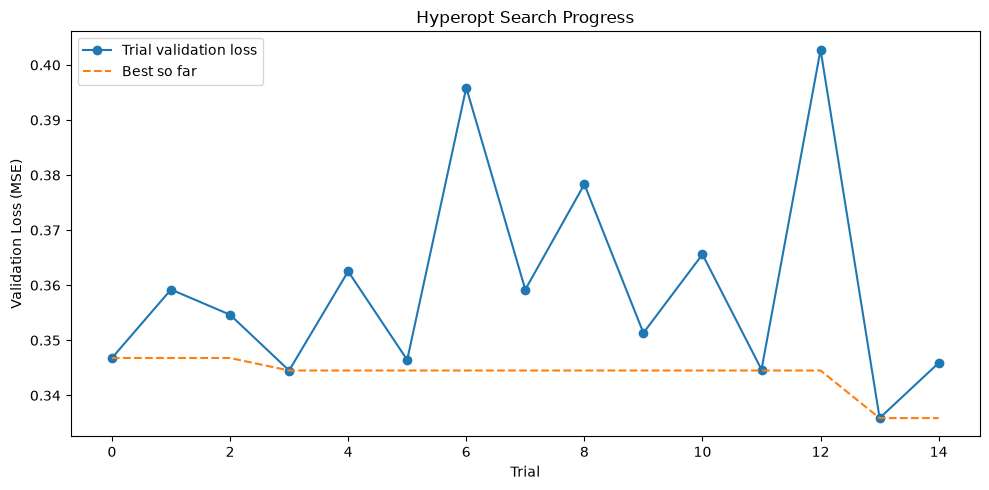

In [29]:
# Plot Hyperopt search progress (per-trial loss and best-so-far)

plt.figure(figsize=(10, 5))

plt.plot(
    trial_results_df["trial"],
    trial_results_df["validation_loss"],
    marker="o",
    label="Trial validation loss"
)

plt.plot(
    trial_results_df["trial"],
    trial_results_df["validation_loss"].cummin(),
    linestyle="--",
    label="Best so far"
)

plt.title("Hyperopt Search Progress")
plt.xlabel("Trial")
plt.ylabel("Validation Loss (MSE)")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/hyperopt_trials.png")
plt.show()

## 9. Final Model Training

In [30]:
# Unpack the best hyperparameters found by Hyperopt

d_model = best_params["architecture"]["d_model"]
num_heads = best_params["architecture"]["num_heads"]
num_layers = best_params["num_layers"]
dim_feedforward = best_params["dim_feedforward"]
dropout = best_params["dropout"]
learning_rate = best_params["learning_rate"]
sequence_length = best_params["sequence_length"]
batch_size = best_params["batch_size"]

print("Using hyperparameters:")
print(best_params)

Using hyperparameters:
{'architecture': {'d_model': 64, 'num_heads': 8}, 'batch_size': 128, 'dim_feedforward': 256, 'dropout': 0.026655554419751235, 'learning_rate': 0.0006218296138458018, 'num_layers': 1, 'sequence_length': 48}


In [31]:
# Train and evaluate the final model across multiple seeds to quantify run-to-run variance

final_epochs = 50
final_patience = 5
final_seeds = [42, 43, 44]

model_path = Path("../models/best_transformer_model.pt")

seed_results = []

for run_index, run_seed in enumerate(final_seeds):
    is_primary_run = (run_index == 0)

    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)

    (
        run_train_dataset,
        run_validation_dataset,
        run_test_dataset,
        run_train_loader,
        run_validation_loader,
        run_test_loader
    ) = build_dataloaders(sequence_length, batch_size, loader_seed=run_seed)

    run_model = ElectricityTransformer(
        input_size=input_size,
        d_model=d_model,
        num_heads=num_heads,
        num_layers=num_layers,
        dim_feedforward=dim_feedforward,
        dropout=dropout
    ).to(device)

    run_optimizer = torch.optim.Adam(
        run_model.parameters(),
        lr=learning_rate
    )

    run_model_path = model_path if is_primary_run else Path(f"../models/_temp_seed_{run_seed}.pt")

    run_train_losses, run_validation_losses, run_best_validation_loss = train_model(
        run_model,
        run_train_loader,
        run_validation_loader,
        criterion,
        run_optimizer,
        device,
        epochs=final_epochs,
        patience=final_patience,
        model_path=run_model_path,
        verbose=is_primary_run
    )

    run_model.load_state_dict(torch.load(run_model_path, map_location=device))
    run_model.eval()

    run_predictions = []
    run_actuals = []

    with torch.no_grad():
        for features, targets in run_test_loader:
            features = features.to(device)
            predictions = run_model(features)
            run_predictions.extend(predictions.cpu().numpy())
            run_actuals.extend(targets.numpy())

    run_predictions = target_scaler.inverse_transform(
        np.array(run_predictions).reshape(-1, 1)
    ).flatten()

    run_actuals = target_scaler.inverse_transform(
        np.array(run_actuals).reshape(-1, 1)
    ).flatten()

    run_mae = mean_absolute_error(run_actuals, run_predictions)
    run_mse = mean_squared_error(run_actuals, run_predictions)
    run_rmse = np.sqrt(run_mse)

    seed_results.append({
        "seed": run_seed,
        "best_validation_loss": run_best_validation_loss,
        "mae": run_mae,
        "mse": run_mse,
        "rmse": run_rmse
    })

    print(
        f"Seed {run_seed} - best val loss: {run_best_validation_loss:.4f} "
        f"- Test MAE: {run_mae:.4f}  MSE: {run_mse:.4f}  RMSE: {run_rmse:.4f}"
    )

    if is_primary_run:
        # Keep the primary run's artifacts as the notebook's canonical results
        model = run_model
        train_losses = run_train_losses
        validation_losses = run_validation_losses
        best_validation_loss = run_best_validation_loss
        test_dataset = run_test_dataset
        test_loader = run_test_loader
        test_predictions = run_predictions
        test_actuals = run_actuals
    else:
        run_model_path.unlink()

Epoch 1/50 - Training Loss: 0.5062 - Validation Loss: 0.3995


Epoch 2/50 - Training Loss: 0.3917 - Validation Loss: 0.3663


Epoch 3/50 - Training Loss: 0.3748 - Validation Loss: 0.3568


Epoch 4/50 - Training Loss: 0.3602 - Validation Loss: 0.3564


Epoch 5/50 - Training Loss: 0.3528 - Validation Loss: 0.3484


...

Epoch 16/50 - Training Loss: 0.3168 - Validation Loss: 0.3441


Epoch 17/50 - Training Loss: 0.3139 - Validation Loss: 0.3566


Epoch 18/50 - Training Loss: 0.3086 - Validation Loss: 0.3513
Early stopping triggered after epoch 18 (no improvement for 5 epochs).
Seed 42 - best val loss: 0.3377 - Test MAE: 0.3191  MSE: 0.2135  RMSE: 0.4621


Seed 43 - best val loss: 0.3282 - Test MAE: 0.3172  MSE: 0.2188  RMSE: 0.4677


Seed 44 - best val loss: 0.3354 - Test MAE: 0.3251  MSE: 0.2132  RMSE: 0.4617


In [32]:
# Summarize test-set performance across seeds

seed_results_df = pd.DataFrame(seed_results)

print(seed_results_df.to_string(index=False))

print(f"\nAcross {len(final_seeds)} seeds:")
for metric in ["mae", "mse", "rmse"]:
    print(f"{metric.upper()}: mean={seed_results_df[metric].mean():.4f}  std={seed_results_df[metric].std():.4f}")

 seed  best_validation_loss      mae      mse     rmse
   42              0.337719 0.319118 0.213511 0.462072
   43              0.328167 0.317165 0.218768 0.467726
   44              0.335401 0.325052 0.213157 0.461689

Across 3 seeds:
MAE: mean=0.3204  std=0.0041
MSE: mean=0.2151  std=0.0031
RMSE: mean=0.4638  std=0.0034


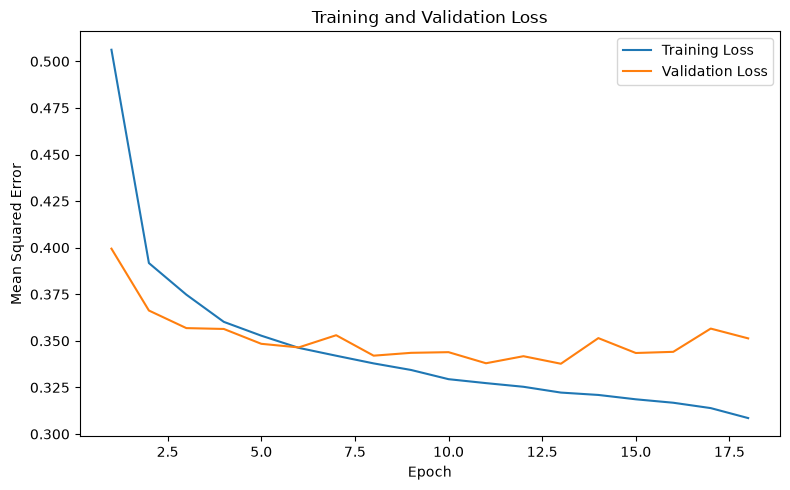

In [33]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    label="Training Loss"
)

plt.plot(
    range(1, len(validation_losses) + 1),
    validation_losses,
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/training_validation_loss.png")
plt.show()

## 10. Evaluation & Baseline Comparison

In [34]:
# Evaluate model performance

mae = mean_absolute_error(
    test_actuals,
    test_predictions
)

mse = mean_squared_error(
    test_actuals,
    test_predictions
)

rmse = np.sqrt(mse)

print(f"Test MAE: {mae:.4f}")
print(f"Test MSE: {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")

Test MAE: 0.3191
Test MSE: 0.2135
Test RMSE: 0.4621


In [35]:
# Baseline: persistence (naive) model — predicts the next value equals the previous hour's actual value

persistence_predictions = test_df[target_column].iloc[
    sequence_length - 1 : sequence_length - 1 + len(test_actuals)
].to_numpy()

baseline_mae = mean_absolute_error(test_actuals, persistence_predictions)
baseline_mse = mean_squared_error(test_actuals, persistence_predictions)
baseline_rmse = np.sqrt(baseline_mse)

print(f"Persistence Baseline MAE: {baseline_mae:.4f}")
print(f"Persistence Baseline MSE: {baseline_mse:.4f}")
print(f"Persistence Baseline RMSE: {baseline_rmse:.4f}")

print(f"\nTransformer improvement over baseline (MAE): {(1 - mae / baseline_mae) * 100:.2f}%")

Persistence Baseline MAE: 0.3730
Persistence Baseline MSE: 0.3308
Persistence Baseline RMSE: 0.5752

Transformer improvement over baseline (MAE): 14.44%


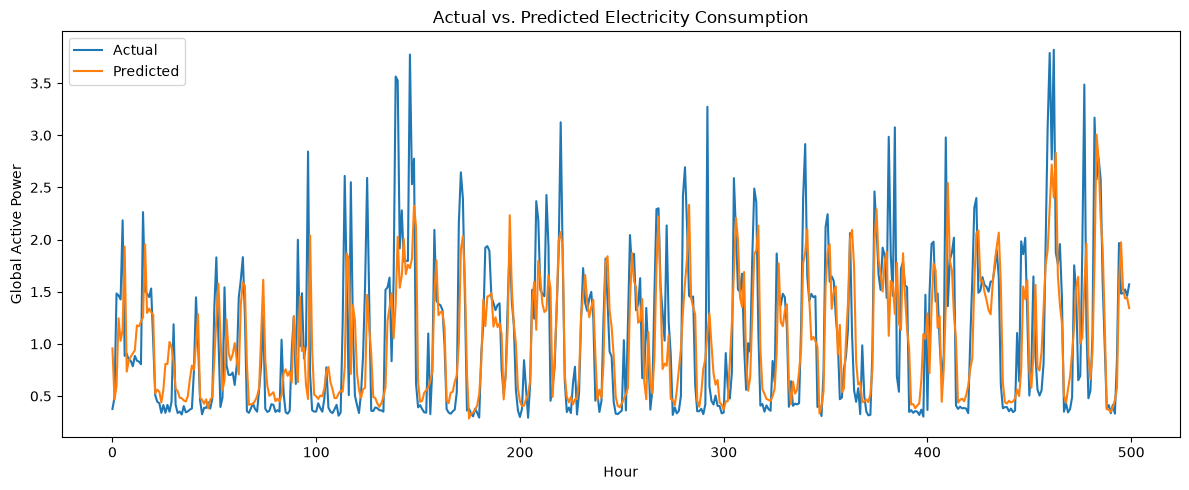

In [36]:
# Plot actual and predicted electricity consumption

plot_length = 500

plt.figure(figsize=(12, 5))

plt.plot(
    test_actuals[:plot_length],
    label="Actual"
)

plt.plot(
    test_predictions[:plot_length],
    label="Predicted"
)

plt.title("Actual vs. Predicted Electricity Consumption")
plt.xlabel("Hour")
plt.ylabel("Global Active Power")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/actual_vs_predicted.png")
plt.show()

## 11. Save Artifacts

In [37]:
# Save model results

test_timestamps = test_df.index[sequence_length : sequence_length + len(test_actuals)]

results_df = pd.DataFrame({
    "Timestamp": test_timestamps,
    "Actual": test_actuals,
    "Predicted": test_predictions
})

results_path = Path("../models/test_predictions.csv")

results_df.to_csv(
    results_path,
    index=False
)

print("Results saved to:", results_path)

Results saved to: ..\models\test_predictions.csv


In [38]:
# Save fitted scalers

feature_scaler_path = Path(
    "../models/feature_scaler.pkl"
)

target_scaler_path = Path(
    "../models/target_scaler.pkl"
)

joblib.dump(
    feature_scaler,
    feature_scaler_path
)

joblib.dump(
    target_scaler,
    target_scaler_path
)

print("Feature scaler saved to:", feature_scaler_path)
print("Target scaler saved to:", target_scaler_path)

Feature scaler saved to: ..\models\feature_scaler.pkl
Target scaler saved to: ..\models\target_scaler.pkl
